# Social Indicators

## Correlation analysis

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv("data/data.csv")

df

,Country Name,Code,Year,Ed Gov Expenditure,Ed Post Secondary,Ec GNI per capita,Ec Gini Index,Birth Rate,Fem Labor Ratio,Fem Parliament Sits,Life Expectancy,Rule of Law
0,Aruba,ABW,2000,21.807711,NaN,20060.0,NaN,14.260,78.202,NaN,72.9393,NaN
1,Aruba,ABW,2001,21.323179,NaN,20340.0,NaN,13.813,NaN,NaN,73.0437,NaN
2,Aruba,ABW,2002,19.757151,NaN,19220.0,NaN,13.337,NaN,NaN,73.1355,NaN
3,Aruba,ABW,2003,NaN,NaN,21020.0,NaN,13.358,NaN,NaN,73.2362,NaN
4,Aruba,ABW,2004,14.902910,NaN,23610.0,NaN,12.540,NaN,NaN,73.2230,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
9819,Zimbabwe,ZWE,2022,NaN,NaN,2580.0,NaN,30.882,83.313,30.566,62.3601,0.391414
9820,Zimbabwe,ZWE,2023,10.688962,NaN,2550.0,NaN,30.410,83.521,30.682,62.7748,0.396527
9821,Zimbabwe,ZWE,2023,10.688962,NaN,2550.0,NaN,30.410,83.522,30.682,62.7748,0.396527
9822,Zimbabwe,ZWE,2024,16.320335,NaN,2400.0,NaN,29.891,83.535,28.090,NaN,0.396732


<Axes: >

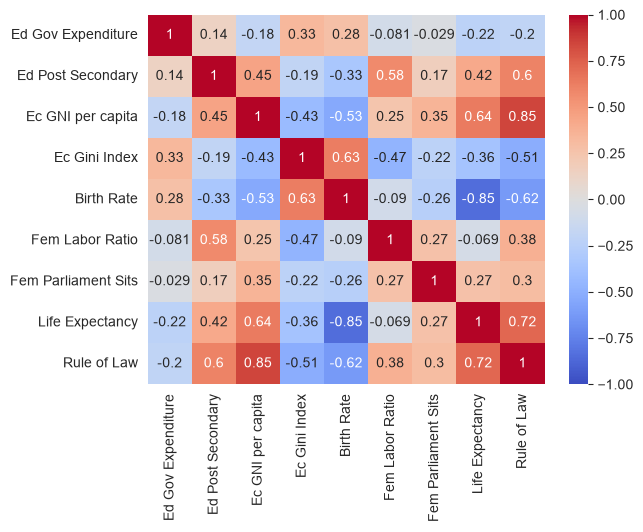

In [3]:
sns.heatmap(
    data = df.drop(columns=['Country Name', 'Code', 'Year']).corr(),
    annot=True,
    vmin=-1,
    vmax=1,
    cmap='coolwarm',
)

This correlation map shows us how each metric correlate with others, based on the whole dataset.

Note: Gini index - statistical dispersion of income, wealth, and consumption inequality (less - better)

Education government expenditure shows a low correlation with almost all indicators except of Gini index and Birth rate. It seems that this is more of a consequence than a cause.

In the opposite, Post secondary rate has a strong correlation with most metrics that shows positive impact on other spheres of life.

Some people might note, that Birth rate decreasing is bad, but a higher Birth rate, in general, correlate with most other metrics in a bad way.

Also, Female parliament sits has not such strong, but often positive relations with other aspects of society.

Rule of law has a remarkably huge impact positive impact on each sphere.

<Axes: xlabel='Fem Labor Ratio', ylabel='Ec Gini Index'>

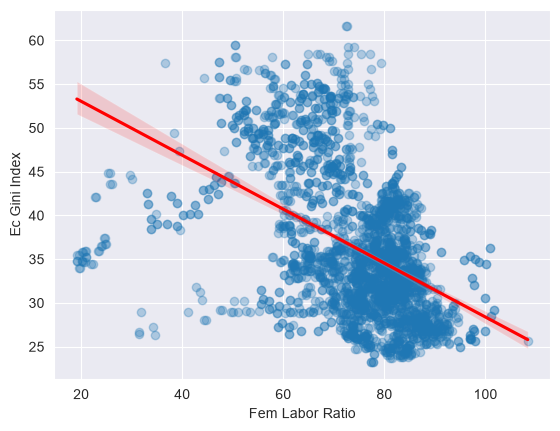

In [4]:
sns.regplot(
    data=df,
    x='Fem Labor Ratio',
    y='Ec Gini Index',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

This trend line shows that higher Gini index usually correlate with lower Female labor ratio.

We could make an assumption about effect of one metric on another one by making a paired t-test.

The paired t-test compare values of one (target) metric in groups with low and high values of another. If the low-values group has lower target values than the high-values group, we could suppose that there is an influence of the metric we split on the target metric. It doesn't show a real causal inference, but excludes randomness in relationship.

Let's define a difference in Gini Index with low and high Female labor force in each country.

We can resample our differences many times to exclude randomness with bootstrapping.

From means of the resampled differences we can get the lower and upper confidence intervals to check the statistical significance.

If the confidence interval 95% doesn't include 0, there is at lease 95% of statistical significance that Female labor force is related with Gini index.

In [5]:
x = 'Fem Labor Ratio'
y = 'Ec Gini Index'


def get_paired_diffs(x, y):
    dfxy = df[['Code', 'Year', x, y]]

    differences = []
    for country in dfxy['Code'].unique():
        c_data = dfxy[dfxy['Code'] == country]
        low = c_data[c_data[x] < c_data[x].median()]
        high = c_data[c_data[x] >= c_data[x].median()]
        if len(low) > 0:
            diff = high[y].mean() - low[y].mean()
            if pd.notnull(diff):
                differences.append(diff)
    return differences

def bootstrap_paired_diffs(diffs, n=10000):
    bootstrap_means = []
    size = len(diffs)
    for _ in range(n):
        resampled_differences = np.random.choice(diffs, size=size, replace=True)
        bootstrap_means.append(np.mean(resampled_differences))
    return bootstrap_means

diffs = get_paired_diffs(x, y)
means = bootstrap_paired_diffs(diffs)
lower_ci = np.percentile(means, 2.5)
upper_ci = np.percentile(means, 97.5)
print(lower_ci, upper_ci)

-1.341031558669594 -0.05858339086956282


In [6]:
t_stat, p_value = stats.ttest_1samp(diffs, 0)
print(p_value)

0.039184108086114555


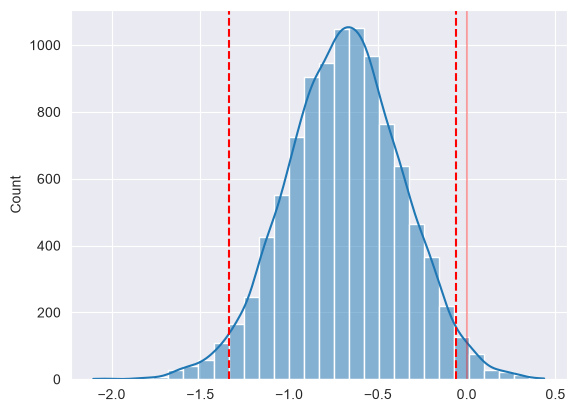

In [24]:
ax = sns.histplot(
    x=means,
    bins=30,
    kde=True
)
ax.axvline(
    lower_ci,
    color='red',
    linestyle='--'
)
ax.axvline(
    upper_ci,
    color='red',
    linestyle='--'
)
ax.axvline(
    0,
    color='#FF000055',
    linestyle='-'
)
plt.show(ax)

This histogram shows the distribution of means we got by bootstrapping differences. Red dashed lines are lower and higher boundaries of 95% cases. The 0 value is out of the boundaries, so the relation is significant, not random.

In [15]:
columns = df.drop(columns=['Country Name', 'Code', 'Year']).columns

def get_diffs(x, y):
    return get_paired_diffs(x, y)

def check_stat_sign(x, y):
    diffs = get_diffs(x, y)
    means = bootstrap_paired_diffs(diffs)
    lower_ci = np.percentile(means, 2.5)
    upper_ci = np.percentile(means, 97.5)
    if lower_ci * upper_ci < 0:
        return 0
    elif lower_ci > 0:
        return 1
    else:
        return -1


checks = pd.DataFrame(
    index=columns,
    columns=columns,
    dtype=float
)
for row in columns:
    for col in columns:
        if row == col:
            checks.loc[row, col] = 0
        else:
            checks.loc[row, col] = check_stat_sign(row, col)

checks

,Ed Gov Expenditure,Ed Post Secondary,Ec GNI per capita,Ec Gini Index,Birth Rate,Fem Labor Ratio,Fem Parliament Sits,Life Expectancy,Rule of Law
Ed Gov Expenditure,0.0,-1.0,0.0,0.0,1.0,0.0,-1.0,0.0,0.0
Ed Post Secondary,0.0,0.0,1.0,0.0,-1.0,1.0,1.0,1.0,0.0
Ec GNI per capita,0.0,1.0,0.0,-1.0,-1.0,1.0,1.0,1.0,0.0
Ec Gini Index,0.0,0.0,0.0,0.0,1.0,0.0,-1.0,-1.0,0.0
Birth Rate,1.0,-1.0,-1.0,1.0,0.0,-1.0,-1.0,-1.0,1.0
Fem Labor Ratio,0.0,1.0,1.0,-1.0,-1.0,0.0,1.0,1.0,0.0
Fem Parliament Sits,0.0,1.0,1.0,-1.0,-1.0,1.0,0.0,1.0,0.0
Life Expectancy,0.0,1.0,1.0,-1.0,-1.0,1.0,1.0,0.0,1.0
Rule of Law,1.0,0.0,-1.0,0.0,1.0,0.0,-1.0,0.0,0.0


In [16]:
p_values_check = pd.DataFrame(
    index=columns,
    columns=columns,
    dtype=float
)
for row in columns:
    for col in columns:
        if row == col:
            p_values_check.loc[row, col] = 0
        else:
            p_values_check.loc[row, col] = 1 if stats.ttest_1samp(get_diffs(row, col), 0)[1] < 0.05 else 0

p_values_check

,Ed Gov Expenditure,Ed Post Secondary,Ec GNI per capita,Ec Gini Index,Birth Rate,Fem Labor Ratio,Fem Parliament Sits,Life Expectancy,Rule of Law
Ed Gov Expenditure,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
Ed Post Secondary,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
Ec GNI per capita,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0
Ec Gini Index,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
Birth Rate,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0
Fem Labor Ratio,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0
Fem Parliament Sits,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0
Life Expectancy,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
Rule of Law,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


<Axes: >

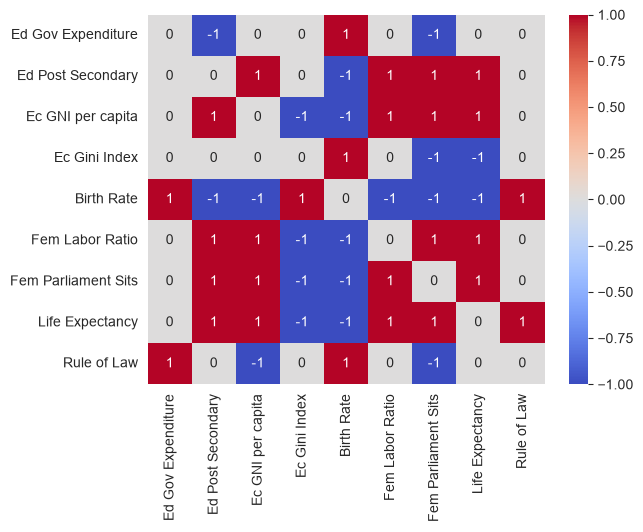

In [17]:
sns.heatmap(
    checks,
    annot=True,
    cmap='coolwarm'
)

This is the full map of possible influence. For each cell, a positive value (1) suggests that the row measure increase the column measure. A negative value (-1) suggests that the row measure decrease the column. A zero value suggests that there is no significant influence of the row measure on the column measure.

<Axes: >

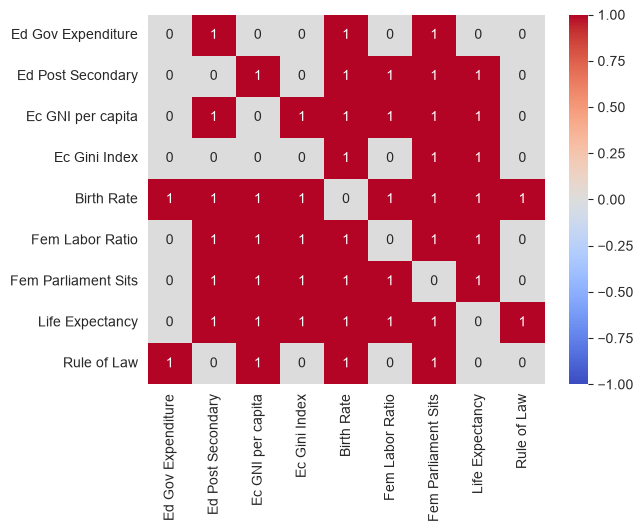

In [18]:
sns.heatmap(
    p_values_check,
    annot=True,
    vmax=1,
    vmin=-1,
    cmap='coolwarm'
)

This map checks that the previous one has correctly calculated statistical significance (just another way to calculate it).

Let's compare the correlation map (based on data from the whole world) with the possible influence map one more time.

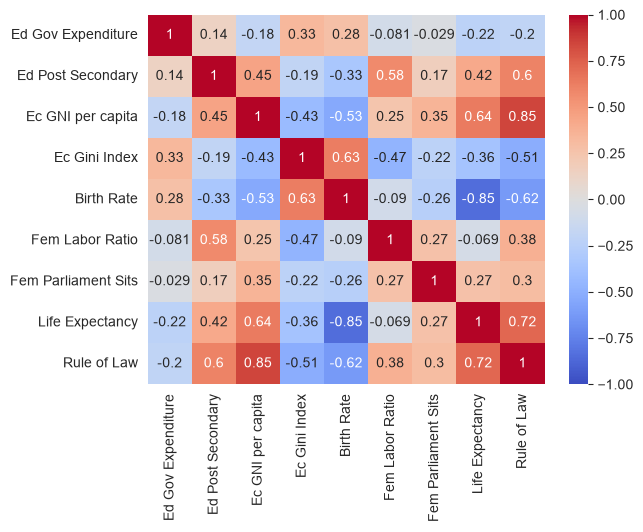

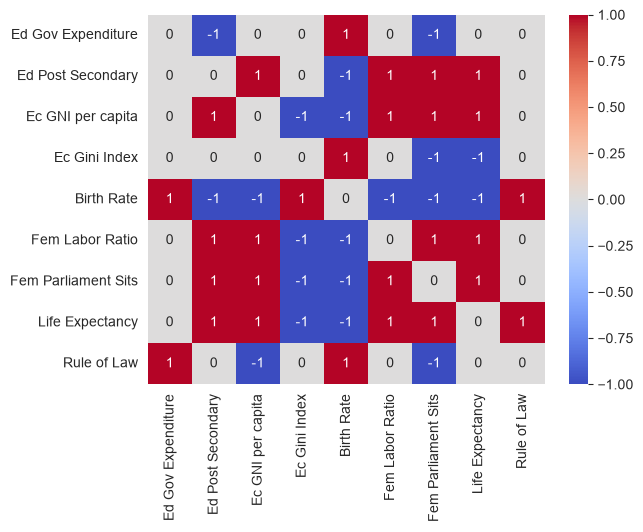

In [13]:
h1 = sns.heatmap(
    data = df.drop(columns=['Country Name', 'Code', 'Year']).corr(),
    annot=True,
    vmin=-1,
    vmax=1,
    cmap='coolwarm',
)
plt.show(h1)
h2 = sns.heatmap(
    checks,
    annot=True,
    cmap='coolwarm'
)
plt.show(h2)